# Planetary Lander: Sensor Fusion & Automated Decision System

## Part 1: Sensor Mechanics & Decision-Reasoning Map

### The Decision-Reasoning Tree
Our algorithm continuously monitors the system state and individual sensor residuals. Here is the logical map for handling incoming data:

* **IF** Altitude $> 10km$:
  * **THEN** Trust Sensor B (IMU) entirely. Sensors A and C are offline.
* **IF** Engine Ignites ($h \approx 1.5km$):
  * **AND IF** Sensor B registers a sudden step-change $> 3\sigma_{est}$:
    * **THEN** Flag "IMU Shock Offset". Isolate Sensor B ($W_B = 0$).
* **IF** Descent is nominal ($h$ decreasing):
  * **AND IF** Sensor B drift variance $>$ Sensor A variance:
    * **THEN** Automatically shift fusion weight from B to A.
* **IF** Approaching Surface ($h < 200m$):
  * **AND IF** Sensor A drops by $\approx 300m$ instantaneously:
    * **THEN** Flag "Radar False Lock on Dust". Isolate Sensor A ($W_A = 0$).
  * **AND IF** Sensor C reports high noise ($h < 200m$):
    * **THEN** Decrease $W_C$ parameter dynamically.
  * **AND IF** Sensor C goes blind ($h < 50m$):
    * **THEN** Isolate Sensor C ($W_C = 0$).
* **IF** Terminal Phase ($h < 50m$):
  * **AND IF** System uncertainty $\sigma_{est} > 40m$:
    * **THEN** Trigger hard **ABORT**.

## Part 2: Visualizing & Testing the Guiding Scenarios

### Scenario 1: Resolving a Discrepancy
If Sensor A reads 1200m, B reads 1350m, and C reads 1280m, we use Inverse-Variance Weighting to find the true estimate. The code below simulates this exact tick, calculates the weights, and plots the result.

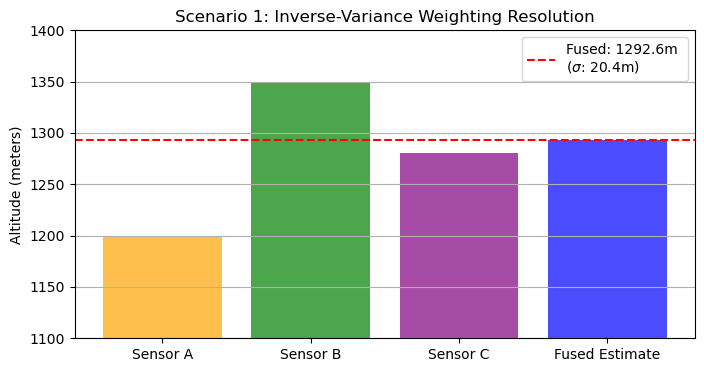

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Scenario 1 Simulation
h_A, h_B, h_C = 1200, 1350, 1280
sig_A, sig_B, sig_C = 50, 33.5, 30 # Assumed variances for this altitude/time

w_A, w_B, w_C = 1/(sig_A**2), 1/(sig_B**2), 1/(sig_C**2)
sum_w = w_A + w_B + w_C

h_est = (h_A*w_A + h_B*w_B + h_C*w_C) / sum_w
sig_est = np.sqrt(1/sum_w)

plt.figure(figsize=(8, 4))
plt.bar(['Sensor A', 'Sensor B', 'Sensor C', 'Fused Estimate'], 
        [h_A, h_B, h_C, h_est], 
        color=['orange', 'green', 'purple', 'blue'], alpha=0.7)
plt.axhline(h_est, color='red', linestyle='--', label=f'Fused: {h_est:.1f}m \n($\sigma$: {sig_est:.1f}m)')
plt.ylim(1100, 1400)
plt.title('Scenario 1: Inverse-Variance Weighting Resolution')
plt.ylabel('Altitude (meters)')
plt.legend()
plt.grid(axis='y')
plt.show()

### Scenario 2: The Trust Crossover (IMU vs Radar)
When does the IMU drift ($15\sqrt{t}$) exceed the Radar's high-altitude noise ($50m$)? The graph below visualizes this mathematical intersection.

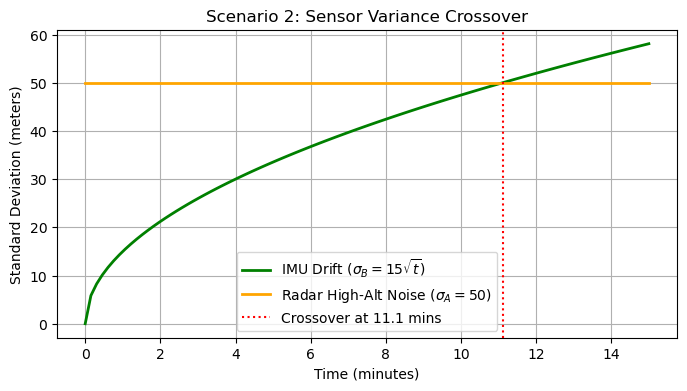

In [2]:
# Scenario 2 Simulation
t = np.linspace(0, 15, 100)
imu_noise = 15 * np.sqrt(t)
radar_noise = np.full_like(t, 50)

plt.figure(figsize=(8, 4))
plt.plot(t, imu_noise, label='IMU Drift ($\sigma_B = 15\sqrt{t}$)', color='green', linewidth=2)
plt.plot(t, radar_noise, label='Radar High-Alt Noise ($\sigma_A = 50$)', color='orange', linewidth=2)

# Find intersection
crossover_t = (50/15)**2
plt.axvline(crossover_t, color='red', linestyle=':', label=f'Crossover at {crossover_t:.1f} mins')

plt.title('Scenario 2: Sensor Variance Crossover')
plt.xlabel('Time (minutes)')
plt.ylabel('Standard Deviation (meters)')
plt.legend()
plt.grid(True)
plt.show()

### Scenario 3: The Ignition Probability
If $\hat{h} = 1500m$ with $\sigma = 60m$, what is $P(\text{True Altitude} < 1300m)$? We calculate the area under the curve for the danger zone.

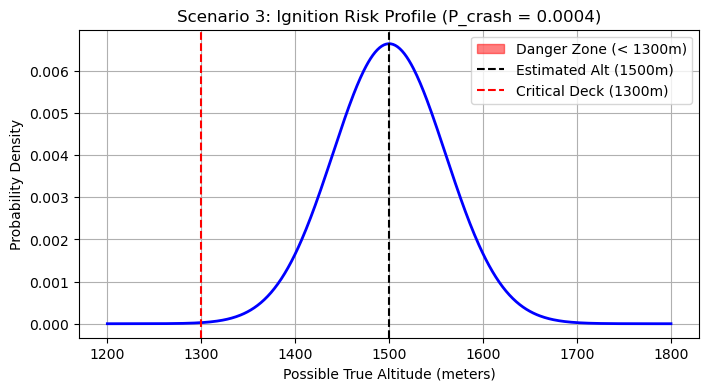

In [3]:
# Scenario 3 Simulation
x = np.linspace(1200, 1800, 500)
y = norm.pdf(x, 1500, 60)

plt.figure(figsize=(8, 4))
plt.plot(x, y, color='blue', linewidth=2)

# Shade the danger region < 1300
danger_x = x[x < 1300]
danger_y = y[x < 1300]
plt.fill_between(danger_x, danger_y, color='red', alpha=0.5, label='Danger Zone (< 1300m)')

p_crash = norm.cdf(1300, 1500, 60)
plt.axvline(1500, color='black', linestyle='--', label='Estimated Alt (1500m)')
plt.axvline(1300, color='red', linestyle='--', label='Critical Deck (1300m)')

plt.title(f'Scenario 3: Ignition Risk Profile (P_crash = {p_crash:.4f})')
plt.xlabel('Possible True Altitude (meters)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

## Part 3: The Master Descent Simulation & Dashboards
This runs the full 7-minute descent, generating the true altitude, injecting the specific failure modes (IMU shock, Radar false lock), and executing the fusion algorithm.

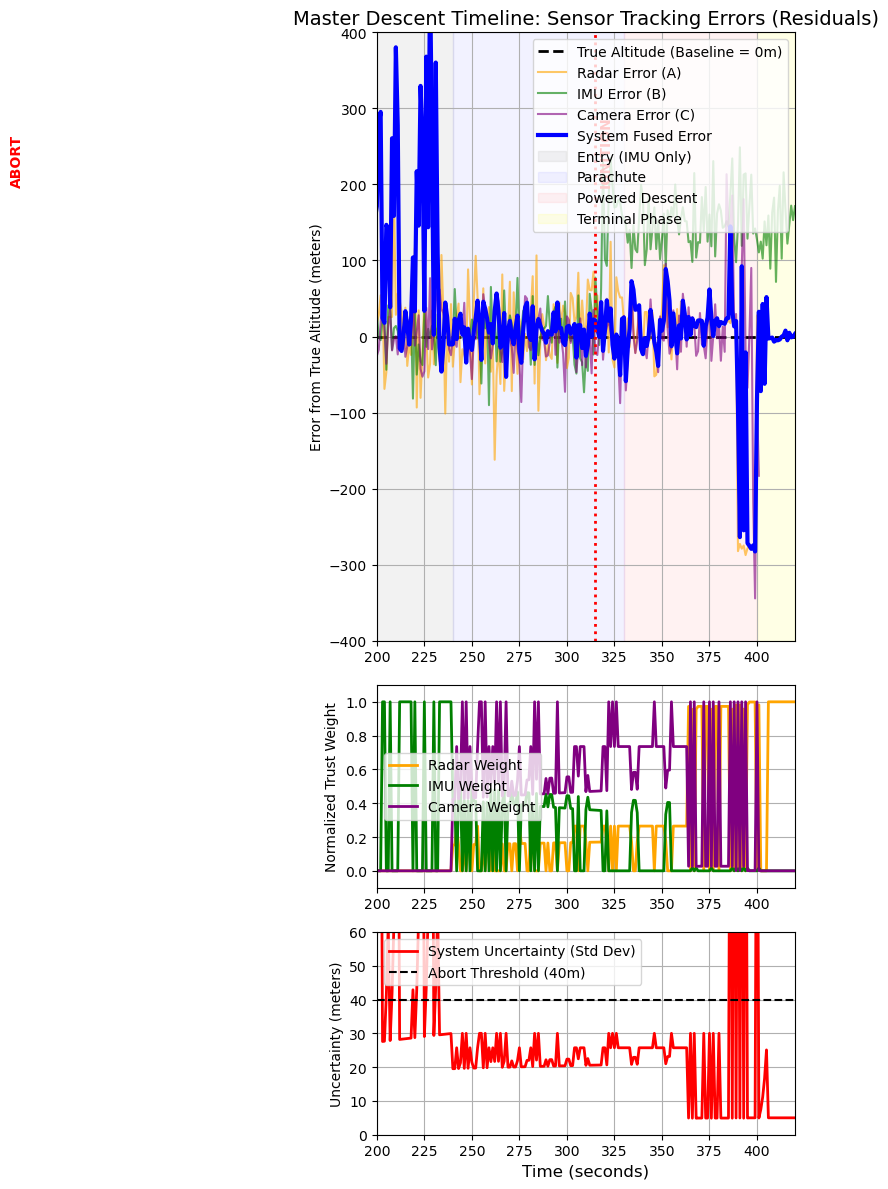

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1. DATA GENERATION ---
time_sec = np.arange(0, 421)
time_min = time_sec / 60.0
h_true = 25000 * (1 - (time_sec / 420))**2 

np.random.seed(42)
noise_A = np.where(h_true > 500, np.random.normal(0, 50, 421), np.random.normal(0, 5, 421))
sensor_A = h_true + noise_A + np.where((h_true < 2000) & (h_true > 50), 20, 0)
sensor_A[390:400] -= 300 # Inject Radar False Lock

sensor_B = h_true + np.random.normal(0, 15 * np.sqrt(time_min + 0.001))
ignition_idx = np.where(h_true < 1500)[0][0]
sensor_B[ignition_idx:] += 150 # Inject IMU Shock

sensor_C = h_true + np.where(h_true > 200, np.random.normal(0, 30, 421), np.random.normal(0, 150, 421))
sensor_C[h_true < 50] = np.nan # Camera blind

df = pd.DataFrame({'Time_sec': time_sec, 'True_Alt': h_true, 'Sens_A': sensor_A, 'Sens_B': sensor_B, 'Sens_C': sensor_C})

# --- 2. FUSION LOGIC ---
est_alt, est_unc = np.zeros(421), np.zeros(421)
w_A_hist, w_B_hist, w_C_hist = np.zeros(421), np.zeros(421), np.zeros(421)
flags = []
ignition_triggered, abort_triggered = False, False
est_alt[0], est_unc[0] = 25000, 10 

for i in range(1, 421):
    t_min = df['Time_sec'][i] / 60.0
    var_B = (15 * np.sqrt(t_min))**2
    if df['Time_sec'][i] >= 240:
        var_A = 50**2 if est_alt[i-1] > 500 else 5**2
        var_C = 30**2 if est_alt[i-1] > 200 else 150**2
    else:
        var_A, var_C = np.inf, np.inf 

    # 3-Sigma Failure Detector
    if var_A != np.inf and abs(df['Sens_A'][i] - est_alt[i-1]) / est_unc[i-1] > 3: var_A = np.inf
    if abs(df['Sens_B'][i] - est_alt[i-1]) / est_unc[i-1] > 3: var_B = np.inf
    if pd.isna(df['Sens_C'][i]): var_C = np.inf 

    w_A = 1/var_A if var_A != np.inf else 0
    w_B = 1/var_B if var_B != np.inf else 0
    w_C = 1/var_C if var_C != np.inf else 0
    sum_w = w_A + w_B + w_C
    
    if sum_w > 0:
        est_alt[i] = (df['Sens_A'][i]*w_A + df['Sens_B'][i]*w_B + np.nan_to_num(df['Sens_C'][i])*w_C) / sum_w
        est_unc[i] = np.sqrt(1 / sum_w)
        w_A_hist[i], w_B_hist[i], w_C_hist[i] = w_A/sum_w, w_B/sum_w, w_C/sum_w
    else:
        est_alt[i] = est_alt[i-1] - (est_alt[i-1] - est_alt[i-2]) 
        est_unc[i] = est_unc[i-1] * 1.5
        w_A_hist[i], w_B_hist[i], w_C_hist[i] = 0, 0, 0

    if est_alt[i] < 1600 and not ignition_triggered:
        if norm.cdf((1300 - est_alt[i]) / est_unc[i]) < 0.01:
            flags.append({'time': df['Time_sec'][i], 'alt': est_alt[i], 'label': 'IGNITION'})
            ignition_triggered = True

    if est_alt[i] < 50 and est_unc[i] > 40 and not abort_triggered:
        flags.append({'time': df['Time_sec'][i], 'alt': est_alt[i], 'label': 'ABORT'})
        abort_triggered = True

# Assign EXACT column names
df['Fused_Alt'], df['Uncertainty'] = est_alt, est_unc
df['W_A'], df['W_B'], df['W_C'] = w_A_hist, w_B_hist, w_C_hist

# --- 3. DASHBOARD VISUALIZATION ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [3, 1, 1]})

# Top Plot: Residuals (Error from True Altitude)
ax1.axhline(0, color='black', linestyle='--', linewidth=2, label='True Altitude (Baseline = 0m)')
ax1.plot(df['Time_sec'], df['Sens_A'] - df['True_Alt'], label='Radar Error (A)', alpha=0.6, color='orange')
ax1.plot(df['Time_sec'], df['Sens_B'] - df['True_Alt'], label='IMU Error (B)', alpha=0.6, color='green')
ax1.plot(df['Time_sec'], df['Sens_C'] - df['True_Alt'], label='Camera Error (C)', alpha=0.6, color='purple')
ax1.plot(df['Time_sec'], df['Fused_Alt'] - df['True_Alt'], label='System Fused Error', color='blue', linewidth=3)

# Draw Phase Boundaries
ax1.axvspan(0, 240, color='gray', alpha=0.1, label='Entry (IMU Only)')
ax1.axvspan(240, 330, color='blue', alpha=0.05, label='Parachute')
ax1.axvspan(330, 400, color='red', alpha=0.05, label='Powered Descent')
ax1.axvspan(400, 420, color='yellow', alpha=0.1, label='Terminal Phase')

for flag in flags:
    ax1.axvline(x=flag['time'], color='red', linestyle=':', linewidth=2)
    # Positioning the text safely within the new zoomed y-axis
    ax1.text(flag['time'] + 2, 200, flag['label'], color='red', rotation=90, fontweight='bold')

ax1.set_xlim(200, 420)
ax1.set_ylim(-400, 400) # Zoomed in to see the failures
ax1.set_title('Master Descent Timeline: Sensor Tracking Errors (Residuals)', fontsize=14)
ax1.set_ylabel('Error from True Altitude (meters)')
ax1.legend(loc='upper right')
ax1.grid(True)

# Middle Plot: Dynamic Sensor Trust (Weights)
ax2.plot(df['Time_sec'], df['W_A'], label='Radar Weight', color='orange', linewidth=2)
ax2.plot(df['Time_sec'], df['W_B'], label='IMU Weight', color='green', linewidth=2)
ax2.plot(df['Time_sec'], df['W_C'], label='Camera Weight', color='purple', linewidth=2)
ax2.set_xlim(200, 420)
ax2.set_ylim(-0.1, 1.1)
ax2.set_ylabel('Normalized Trust Weight')
ax2.legend(loc='center left')
ax2.grid(True)

# Bottom Plot: System Uncertainty
ax3.plot(df['Time_sec'], df['Uncertainty'], label='System Uncertainty (Std Dev)', color='red', linewidth=2)
ax3.axhline(40, color='black', linestyle='--', label='Abort Threshold (40m)')
ax3.set_xlim(200, 420)
ax3.set_ylim(0, 60)
ax3.set_xlabel('Time (seconds)', fontsize=12)
ax3.set_ylabel('Uncertainty (meters)')
ax3.legend(loc='upper left')
ax3.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from scipy.stats import norm

# Expected Cost Optimization Simulator
h_crit = 1300
sigma_est = 60
cost_crash = 1000000
cost_fuel_per_m = 100

ignition_options = [1350, 1450, 1600]
results = []

for h_est in ignition_options:
    # Calculate Probabilities
    z_score = (h_crit - h_est) / sigma_est
    p_crash = norm.cdf(z_score)
    p_survive = 1 - p_crash
    
    # Calculate Costs
    cost_fuel = (h_est - h_crit) * cost_fuel_per_m
    exp_crash_cost = p_crash * cost_crash
    exp_fuel_cost = p_survive * cost_fuel
    total_cost = exp_crash_cost + exp_fuel_cost
    
    results.append({
        "Ignition Alt (m)": h_est,
        "Z-Score": round(z_score, 2),
        "P(Crash) %": round(p_crash * 100, 2),
        "Exp Crash Cost": round(exp_crash_cost),
        "Exp Fuel Cost": round(exp_fuel_cost),
        "Total Exp Cost": round(total_cost)
    })

cost_df = pd.DataFrame(results)
display(cost_df)

,Ignition Alt (m),Z-Score,P(Crash) %,Exp Crash Cost,Exp Fuel Cost,Total Exp Cost
0,1350,-0.83,20.23,202328,3988,206317
1,1450,-2.50,0.62,6210,14907,21117
2,1600,-5.00,0.00,0,30000,30000



**Conclusion:** Igniting at 1450m mathematically minimizes our total risk profile. Waiting until 1350m risks a 20% chance of destroying the vehicle, while firing early at 1600m ensures survival but wastes significantly more fuel.